# EAZY Performance Analysis

<p>The following code performs an analysis of the EAZY photometric redshift performanced with the following functions:</p>

- Comparsion with MSAEXP spectroscopic redshift
- Visualisation of select SEDs (WIP)
- Image retrieval for select targets (WIP)

#### zspec Performance Plot

σ_NMAD = 0.1004, Outlier fraction = 37.36%


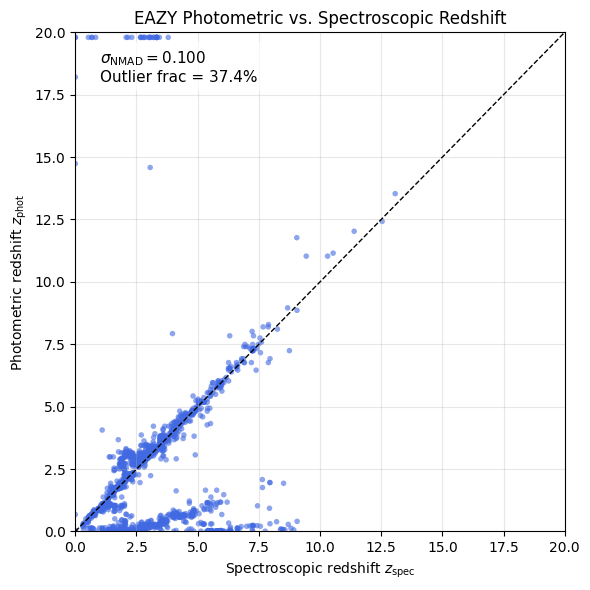

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table


def plot_zphot_zspec(zout_path, zmax=6, outlier_thresh=0.15):
    """
    Create a z_phot vs z_spec diagnostic plot similar to threedhst.eazyPy.zPhot_zSpec,
    including σ_NMAD and outlier fraction.

    Parameters
    ----------
    zout_path : str
        Path to the EAZY output file (photz.zout).
    save_as : str, optional
        Output filename for the plot (default: 'zphot_zspec.png').
    zmax : float, optional
        Maximum redshift for axes (default: 6).
    outlier_thresh : float, optional
        |Δz|/(1+z_spec) threshold for outliers (default: 0.15).
    """
    # --- Load EAZY output
    zout = Table.read(zout_path, format='ascii')

    # --- Identify columns automatically
    colnames = [c.lower() for c in zout.colnames]
    if 'z_spec' in colnames:
        zspec_col = zout.colnames[colnames.index('z_spec')]
    elif 'zspec' in colnames:
        zspec_col = zout.colnames[colnames.index('zspec')]
    else:
        raise ValueError("No spectroscopic redshift column found in .zout file.")

    if 'z_a' in colnames:
        zphot_col = zout.colnames[colnames.index('z_a')]
    elif 'z_phot' in colnames:
        zphot_col = zout.colnames[colnames.index('z_phot')]
    else:
        raise ValueError("No photometric redshift column (z_a / z_phot) found in .zout file.")

    # --- Extract arrays and clean NaNs
    zspec = np.array(zout[zspec_col])
    zphot = np.array(zout[zphot_col])
    mask1 = zspec >= 0
    mask2 = zphot >= 0

    mask = mask1 & mask2
    zspec, zphot = zspec[mask], zphot[mask]

    # --- Compute scatter metrics
    dz = (zphot - zspec) / (1 + zspec)
    dz = dz[np.isfinite(dz)]
    sigma_nmad = 1.48 * np.median(np.abs(dz - np.median(dz)))
    outlier_frac = np.mean(np.abs(dz) > outlier_thresh)

    # --- Plot
    plt.figure(figsize=(6, 6))
    plt.scatter(zspec, zphot, s=16, alpha=0.6, color='royalblue', edgecolor='none', label='Data')
    plt.plot([0, zmax], [0, zmax], 'k--', lw=1, label='1:1')
    plt.xlabel(r'Spectroscopic redshift $z_{\rm spec}$')
    plt.ylabel(r'Photometric redshift $z_{\rm phot}$')
    plt.xlim(0, zmax)
    plt.ylim(0, zmax)
    plt.grid(alpha=0.3)

    # --- Annotate performance
    txt = (rf"$\sigma_{{\rm NMAD}} = {sigma_nmad:.3f}$" + "\n" +
           rf"Outlier frac = {outlier_frac*100:.1f}%")
    plt.text(0.05*zmax, 0.9*zmax, txt, fontsize=11, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    plt.title('EAZY Photometric vs. Spectroscopic Redshift')
    plt.tight_layout()
    # plt.savefig(save_as, dpi=150)
    # plt.close()

    # print(f"✅ Plot saved to {save_as}")
    print(f"σ_NMAD = {sigma_nmad:.4f}, Outlier fraction = {outlier_frac*100:.2f}%")

plot_zphot_zspec('../inputs/OUTPUT/photz.zout', zmax=20)

#Delete the comment on line 1 and delete last line (incomplete)

In [15]:
RUN_NAME = 'GOODS-S'

cat_path = f'../inputs/{RUN_NAME}_photometry.cat'
cat = Table.read(cat_path, format='ascii')

cat

id,f_nircam_f090w,e_nircam_f090w,f_wfc3-ir_f105w,e_wfc3-ir_f105w,f_wfc3-ir_f110w,e_wfc3-ir_f110w,f_nircam_f115w,e_nircam_f115w,f_niriss_f115w,e_niriss_f115w,f_wfc3-ir_f125w,e_wfc3-ir_f125w,f_wfc3-ir_f140w,e_wfc3-ir_f140w,f_nircam_f150w,e_nircam_f150w,f_niriss_f150w,e_niriss_f150w,f_wfc3-ir_f160w,e_wfc3-ir_f160w,f_nircam_f182m,e_nircam_f182m,f_nircam_f200w,e_nircam_f200w,f_niriss_f200w,e_niriss_f200w,f_nircam_f210m,e_nircam_f210m,f_nircam_f277w,e_nircam_f277w,f_nircam_f335m,e_nircam_f335m,f_wfc3-uvis_f350lp,e_wfc3-uvis_f350lp,f_nircam_f356w,e_nircam_f356w,f_nircam_f410m,e_nircam_f410m,f_nircam_f430m,e_nircam_f430m,f_acs_f435w,e_acs_f435w,f_nircam_f444w,e_nircam_f444w,f_nircam_f460m,e_nircam_f460m,f_acs_f475w,e_acs_f475w,f_nircam_f480m,e_nircam_f480m,f_acs_f606w,e_acs_f606w,f_wfc3-uvis_f606w,e_wfc3-uvis_f606w,f_acs_f775w,e_acs_f775w,f_acs_f814w,e_acs_f814w,f_wfc3-uvis_f814w,e_wfc3-uvis_f814w,f_acs_f850lp,e_acs_f850lp,f_wfc3-uvis_f850lp,e_wfc3-uvis_f850lp,z_spec
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
51,-99.0,10000000000.0,0.0593475,0.007747864,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,0.05836483,0.005813961,0.07454174,0.01529728,-99.0,10000000000.0,-99.0,10000000000.0,0.07680882,0.008678746,0.155576,0.004910302,-99.0,10000000000.0,-99.0,10000000000.0,0.1186988,0.005949958,-99.0,10000000000.0,-99.0,10000000000.0,0.04048118,0.003438643,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,0.02121764,0.003075538,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,0.05556428,0.001915305,-99.0,10000000000.0,0.057534,0.004491354,0.0670911,0.001731345,-99.0,10000000000.0,0.06828083,0.004686326,-99.0,10000000000.0,2.8997
70,-99.0,10000000000.0,0.01354786,0.007710654,0.01639714,0.004596723,-99.0,10000000000.0,-99.0,10000000000.0,0.02268065,0.004125744,0.03173412,0.01544646,-99.0,10000000000.0,-99.0,10000000000.0,0.02316182,0.005106059,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,0.0194116,0.002879063,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,0.01309401,0.001772172,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,0.02514552,0.002325826,-99.0,10000000000.0,0.02807122,0.005344385,0.0318174,0.001566007,-99.0,10000000000.0,0.02745068,0.004666157,-99.0,10000000000.0,3.0992
161,-99.0,10000000000.0,0.04325883,0.007784499,0.04980086,0.004766304,-99.0,10000000000.0,-99.0,10000000000.0,0.05633038,0.004780914,0.06612275,0.01557286,-99.0,10000000000.0,-99.0,10000000000.0,0.1200044,0.006138493,0.2241059,0.003756392,-99.0,10000000000.0,-99.0,10000000000.0,0.2438887,0.004796057,-99.0,10000000000.0,-99.0,10000000000.0,0.01667261,0.003198988,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,0.008990909,0.001841468,0.5182109,0.00537357,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,0.01992272,0.001908054,-99.0,10000000000.0,0.0264787,0.00460572,0.03409667,0.001679477,-99.0,10000000000.0,0.0365191,0.004624361,-99.0,10000000000.0,2.701
162,-99.0,10000000000.0,0.2544747,0.008272586,0.2781704,0.004947456,-99.0,10000000000.0,-99.0,10000000000.0,0.3152914,0.004981153,0.3086511,0.01510506,-99.0,10000000000.0,-99.0,10000000000.0,0.4888257,0.00622609,0.4535697,0.003849984,-99.0,10000000000.0,-99.0,10000000000.0,0.7043064,0.00513045,-99.0,10000000000.0,-99.0,10000000000.0,0.1977301,0.003311004,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,0.1427426,0.002009383,0.5049547,0.0053151

In [16]:
zout_path = '../inputs/OUTPUT/photz.zout'
zout = Table.read(zout_path, format='ascii')
zout

id,z_spec,z_a,z_m1,chi_a,l68,u68,l95,u95,l99,u99,nfilt,q_z,z_peak,peak_prob,z_mc
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64
51,2.8997,3.493,3.535,43.03912,3.437,3.655,3.393,3.723,3.383,3.747,12,1.76119,3.5343,0.999,3.5048
70,3.0992,0.445,1.583,18.02155,0.358,3.358,0.191,3.494,0.101,3.606,11,1059070000.0,0.4442,0.601,0.2833
161,2.701,3.108,3.102,9.225253,3.025,3.187,2.901,3.24,2.826,3.292,14,0.390721,3.1023,0.999,3.1467
162,2.3445,3.108,3.119,292.6653,3.064,3.167,3.05,3.204,3.04,3.211,14,4.55549,3.1139,0.87,3.1211
168,4.0408,4.216,4.188,61.28473,4.105,4.272,4.0,4.292,3.937,4.321,14,2.25445,4.1875,0.997,4.2586
170,4.8214,4.936,4.947,18.65328,4.85,5.055,4.734,5.137,4.63,5.23,12,1.24302,4.9467,0.998,4.9316
183,1.9627,2.503,2.281,16.82446,1.84,2.591,1.685,2.68,1.617,2.767,12,2.17503,2.5392,0.619,2.5242
191,2.9193,3.448,3.454,34.65374,3.396,3.51,3.365,3.556,3.249,3.605,12,1.37387,3.4545,0.997,3.4077
194,3.5979,3.914,3.908,64.08363,3.827,3.984,3.781,4.075,3.725,4.134,14,2.37795,3.906,0.988,3.9382


In [78]:
diagnostic_tab = zout['id', 'z_spec', 'z_a']
diagnostic_tab['delta_z'] = (zout['z_a'] - zout['z_spec']) / (1 + zout['z_spec'])
len_diagnostic = len(diagnostic_tab) # Account for mismatch from EAZY termination issue - FIX IF POSSIBLE

for col_name in cat.colnames:
    if col_name.startswith('f_'):
        diagnostic_tab[col_name] = cat[col_name][0:len_diagnostic]

diagnostic_tab.sort('delta_z', reverse=True)

diagnostic_tab[:10]

id,z_spec,z_a,delta_z,f_nircam_f090w,f_wfc3-ir_f105w,f_wfc3-ir_f110w,f_nircam_f115w,f_niriss_f115w,f_wfc3-ir_f125w,f_wfc3-ir_f140w,f_nircam_f150w,f_niriss_f150w,f_wfc3-ir_f160w,f_nircam_f182m,f_nircam_f200w,f_niriss_f200w,f_nircam_f210m,f_nircam_f277w,f_nircam_f335m,f_wfc3-uvis_f350lp,f_nircam_f356w,f_nircam_f410m,f_nircam_f430m,f_acs_f435w,f_nircam_f444w,f_nircam_f460m,f_acs_f475w,f_nircam_f480m,f_acs_f606w,f_wfc3-uvis_f606w,f_acs_f775w,f_acs_f814w,f_wfc3-uvis_f814w,f_acs_f850lp,f_wfc3-uvis_f850lp
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
20308,0.0,19.798,19.798,0.1097986,0.2147603,-99.0,0.339103,-99.0,0.2581867,0.2184738,0.3395641,-99.0,0.2195176,0.307249,0.3155098,-99.0,0.3264672,0.1812038,0.1816753,0.02133232,0.1914341,0.1752464,-99.0,0.003212092,0.1400203,-99.0,-99.0,-99.0,0.003774585,-99.0,0.04328797,0.07753968,-99.0,0.1500409,-99.0
15688,0.0004,19.798,19.78968412634946,0.2248556,0.4460113,-99.0,0.6569699,-99.0,0.598217,0.5932999,0.8843298,-99.0,0.6096324,0.8316229,0.8962303,-99.0,0.9353584,0.5642621,0.5852344,0.02624472,0.6109408,0.5955784,-99.0,-8.805982e-05,0.4743215,-99.0,-99.0,-99.0,0.004114657,-99.0,0.05614733,0.09662413,-99.0,0.2044195,-99.0
19929,0.0033,18.206,18.142828665404164,0.002583576,-0.0006667693,-99.0,0.01331462,-99.0,0.002869216,0.002458805,0.006179712,-99.0,0.000816076,0.009617991,0.004687222,-99.0,0.009737009,0.002206694,0.0003267688,0.00260794,0.01002568,0.0383057,-99.0,0.0005706323,0.02973255,-99.0,-99.0,-99.0,5.310493e-05,-99.0,-3.986077e-05,-0.001889109,-99.0,0.000142832,-99.0
34611,0.0,14.741,14.741,-99.0,0.3164451,-99.0,-99.0,-99.0,0.5668931,0.551225,-99.0,-99.0,0.3786429,0.2417962,-99.0,-99.0,0.6365174,-99.0,-99.0,0.003513095,-99.0,-99.0,-99.0,-0.001440791,0.761787,-99.0,-99.0,-99.0,-0.002418375,-99.0,0.00145162,0.02031043,-99.0,0.07266054,-99.0
3019,0.5331,19.798,12.565977431348246,-99.0,9.177885,-99.0,-99.0,-99.0,12.04461,13.78093,-99.0,-99.0,15.42494,25.72068,-99.0,-99.0,28.02788,-99.0,-99.0,2.305959,-99.0,-99.0,-99.0,0.2194564,13.46091,-99.0,-99.0,-99.0,1.970609,-99.0,6.135376,6.946356,-99.0,8.224056,8.795713
51105,0.6651,19.798,11.490541108642123,2.046022,2.484596,-99.0,3.603268,-99.0,3.106497,3.472909,5.78844,-99.0,4.067988,7.657848,8.347218,-99.0,8.747133,9.731403,9.281124,0.5536767,8.749401,7.374616,-99.0,0.1627983,7.36889,-99.0,0.2263414,-99.0,0.4761239,-99.0,1.440081,1.55642,-99.0,1.949898,-99.0
9583,0.6907,19.798,11.30141361566215,-99.0,0.4734956,-99.0,-99.0,-99.0,0.4821397,0.3757855,-99.0,-99.0,0.3744768,0.6063514,-99.0,-99.0,0.6136322,-99.0,-99.0,0.4971998,-99.0,-99.0,0.2899605,0.4307565,0.3016815,0.2793333,-99.0,0.2587253,0.4825703,-99.0,0.6838812,0.6616133,-99.0,0.7219284,-99.0
13402,0.8329,19.798,10.34704566533908,2.074922,2.255408,-99.0,3.506836,-99.0,2.816347,3.138886,5.092514,-99.0,3.499686,6.058119,6.870531,-99.0,6.573157,7.697889,7.374133,0.4112263,6.834981,5.739922,-99.0,0.03007983,4.725718,-99.0,-99.0,-99.0,0.279564,-99.0,1.139861,1.38231,-99.0,1.881583,-99.0
16728,2.0755,19.798,5.7624776459112335,0.09703815,0.09070702,-99.0,0.1372368,-99.0,0.1057474,0.1744092,0.2782922,-99.0,0.2027558,0.1114867,0.1950343,-99.0,0.308845,0.1287402,0.1540473,0.08969974,0.1369502,0.1345513,-99.0,0.08316612,0.1244688,-99.0,-99.0,-99.0,0.08775041,-99.0,0.09072347,0.09406384,-99.0,0.09363514,-99.0


In [ ]:
from pathlib import Path

# Match pivot to DAWN filter name

def pivot_wavelength(wave, throughput):
    """
    Compute pivot wavelength.
    
    Parameters
    ----------
    wave : array
        Wavelength array (same units throughout, e.g. Angstrom or micron)
    throughput : array
        Dimensionless system throughput
    
    Returns
    -------
    lambda_pivot : float
        Pivot wavelength in same units as `wave`
    """
    num = np.trapz(wave * throughput, wave)
    den = np.trapz(throughput / wave, wave)
    return np.sqrt(num / den)

# Step 1 - Identify pivot wavelengths for each filter
filter_dirs = {
    "nircam": Path("../throughputs/nircam_throughputs"),
    "niriss": Path("../throughputs/niriss_throughputs"),
    "wfc3-ir":   Path("../throughputs/wfc3-ir_throughputs"),
    "wfc3-uvis": Path("../throughputs/wfc3-uvis_throughputs"),
    "acs":    Path("../throughputs/acs_throughputs"),
}

pivot_dict = {}

import re

filter_cat = []
for col in diagnostic_tab.colnames:
    if col.startswith("f_"):
        # Extract filter name using regex (e.g., f_nircam_f150w → nircam_f150w)
        match = re.match(r"f_(.+)", col)
        if match:
            filter_cat.append(match.group(1))

n_files_found = 0

for filt in filter_cat:
    instrument, filter = filt.split("_")  # Get instrument prefix (e.g., nircam)
    for file in filter_dirs[instrument].glob("*.txt"):
        if file.name.lower().endswith(f"{filter}.txt"):
            data = np.genfromtxt(file, names=None, dtype=float, invalid_raise=False)
            wave = data[:, 0]  # Wavelength
            throughput = data[:, 1]  # Throughput
            if "nircam" in instrument:
                lambda_pivot = pivot_wavelength(wave, throughput) * 10000  # Convert from micron to Angstrom
            elif "niriss" in instrument:
                wave = data[:, 0][1:]  # Wavelength (skip first row which is header)
                throughput = (data[:, 1] * data[:, 2])[1:] # Throughput - deal with unlabeled headers
                lambda_pivot = pivot_wavelength(wave, throughput) * 10000  # Convert from micron to Angstrom
            else:
                lambda_pivot = pivot_wavelength(wave, throughput)
            pivot_dict[filt] = lambda_pivot
            n_files_found += 1

print(n_files_found, "files found and processed.")
pivot_dict

32 files found and processed.


{'nircam_f090w': 9024.004322715571,
 'wfc3-ir_f105w': 10551.04690691064,
 'wfc3-ir_f110w': 11534.458556471893,
 'nircam_f115w': 11540.782060233896,
 'niriss_f115w': 11569.245393753137,
 'wfc3-ir_f125w': 12486.059786098389,
 'wfc3-ir_f140w': 13922.907351513846,
 'nircam_f150w': 15008.986492444132,
 'niriss_f150w': 14931.4452332518,
 'wfc3-ir_f160w': 15369.175706752383,
 'nircam_f182m': 18452.162232046972,
 'nircam_f200w': 19876.00630661438,
 'niriss_f200w': 19859.329259459253,
 'nircam_f210m': 20955.94879405288,
 'nircam_f277w': 27762.299040374513,
 'nircam_f335m': 33622.534099039454,
 'wfc3-uvis_f350lp': 5873.870009138059,
 'nircam_f356w': 35654.89020001737,
 'nircam_f410m': 40829.88273666917,
 'nircam_f430m': 42812.95459815133,
 'acs_f435w': 4329.846864295937,
 'nircam_f444w': 44017.43343383445,
 'nircam_f460m': 46296.16879154382,
 'acs_f475w': 4746.939804554965,
 'nircam_f480m': 48165.46417311176,
 'acs_f606w': 5921.883734588944,
 'wfc3-uvis_f606w': 5889.165748864213,
 'acs_f775w': 7

#### SED Visualization

20308 0.0 19.798 19.798


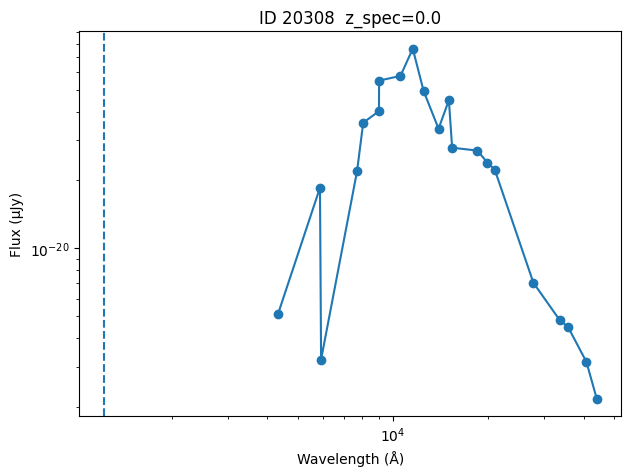

In [85]:
# Select used filters per target & pick out low & high limit
# Classify break fully/partially/not bracketed

# Sort by delta_z and check for systematic trends
import matplotlib.pyplot as plt

def plot_sed(target, pivot_dict):

    wavelengths = []
    fluxes = []

    for col in target.colnames:
        if col.startswith("f_"):
            flux = target[col]

            if flux > 0:  # ignore missing/negative
                filt = col.replace("f_", "")
                if filt in pivot_dict:
                    wavelengths.append(pivot_dict[filt])
                    fluxes.append(flux)

    wavelengths = np.array(wavelengths)
    fluxes = np.array(fluxes)

    # Sort by wavelength
    order = np.argsort(wavelengths)
    wavelengths = wavelengths[order]

    c = 2.998e18  # Å/s
    fluxes = fluxes[order]
    fnu = fluxes * 1e-29  # μJy → erg/s/cm^2/Hz
    flambda = fnu * c / (wavelengths**2)    

    plt.figure(figsize=(7,5))
    plt.scatter(wavelengths, flambda)
    plt.plot(wavelengths, flambda)
    lya = 1216 * (1 + target['z_spec']) # Lyman-alpha wavelength at z_spec
    plt.axvline(lya, linestyle='--')

    plt.xlabel("Wavelength (Å)")
    plt.ylabel("Flux (μJy)")
    plt.title(f"ID {target['id']}  z_spec={target['z_spec']}")
    plt.xscale("log")
    plt.yscale("log")
    plt.show()


target = diagnostic_tab[0]
print(target['id'], target['z_spec'], target['z_a'], target['delta_z'])
plot_sed(target, pivot_dict)